# 🎨 VoxCity 3D 시각화

다양한 방법을 사용하여 3D 복셀 도시 모델을 시각화합니다.

## 시각화 옵션

| 방법 | 설명 | 가장 적합한 용도 |
|--------|-------------|----------|
| **정적 시각화 (PyVista)** | 다중 뷰로 렌더링된 이미지 | 문서, 보고서 |
| **대화형 시각화 (Plotly)** | 노트북 내 3D 탐색 | 데이터 탐색 |
| **OBJ 내보내기** | 외부 소프트웨어에서 열기 | Blender, Rhino, SketchUp |
| **VOX Export (VOX 내보내기)** | MagicaVoxel 형식 | 복셀 아트, 렌더링 |

## 사전 요구 사항

```python
pip install voxcity plotly pyvista
```

INFO | voxcity.voxcity.generator.api | Auto-selecting data sources for: building_complementary_source


Loading formatted geocoded file...


INFO | voxcity.voxcity.generator.api | Detected country for ROI center (139.7650, 35.6850): Japan
INFO | voxcity.voxcity.generator.api | Selected data sources:
INFO | voxcity.voxcity.generator.api | - Buildings(base)=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Buildings(comp)=None
INFO | voxcity.voxcity.generator.api | - LandCover=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Canopy=High Resolution 1m Global Canopy Height Maps | https://gee-community-catalog.org/projects/meta_trees/
INFO | voxcity.voxcity.generator.api | - DEM=DeltaDTM | https://gee-community-catalog.org/projects/delta_dtm/
INFO | voxcity.voxcity.generator.api | - ComplementHeight=10
INFO | voxcity.voxcity.generator.grids | Creating Land Use Land Cover grid
 
INFO | voxcity.voxcity.generator.grids | Data source: OpenStreetMap
INFO | voxcity.voxcity.generator.grids | 
OpenStreetMap Land Cover Classes (source-specific, 0-based indices):
-

Fetching data from Overpass API...
Converting data to GeoJSON format...


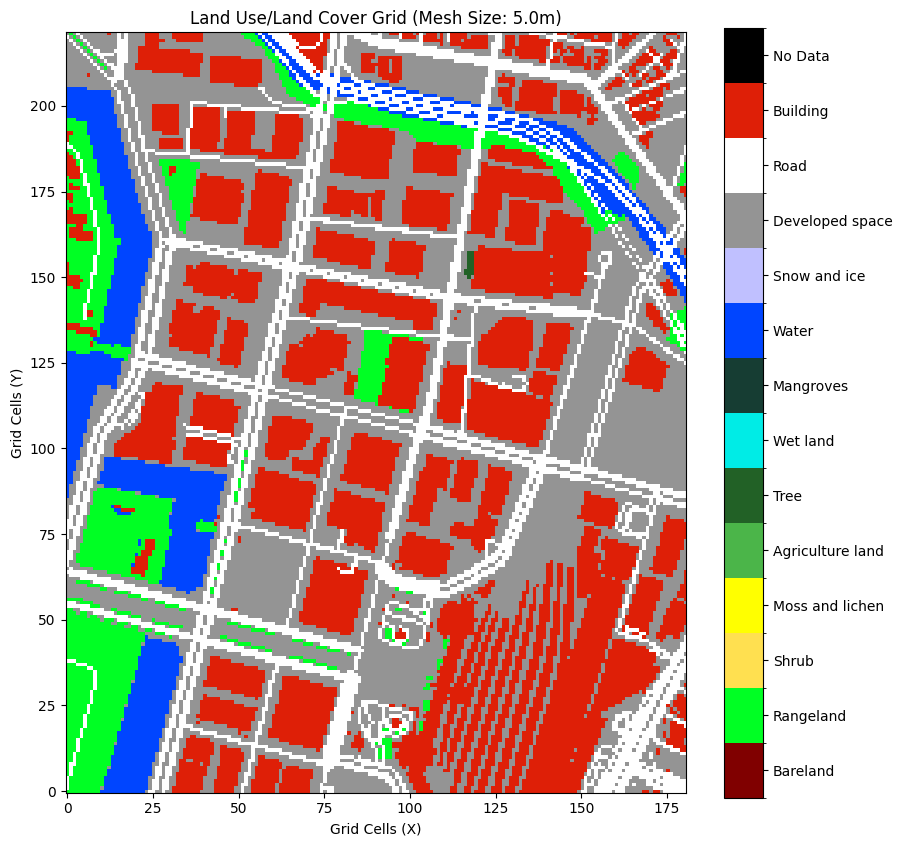

INFO | voxcity.voxcity.generator.grids | Creating Building Height grid
 
INFO | voxcity.voxcity.generator.grids | Base data source: OpenStreetMap
INFO | voxcity.voxcity.generator.grids | Complementary data source: None
INFO | voxcity.voxcity.geoprocessor.raster.buildings | 240 of the total 351 building footprint from the base data source did not have height data.


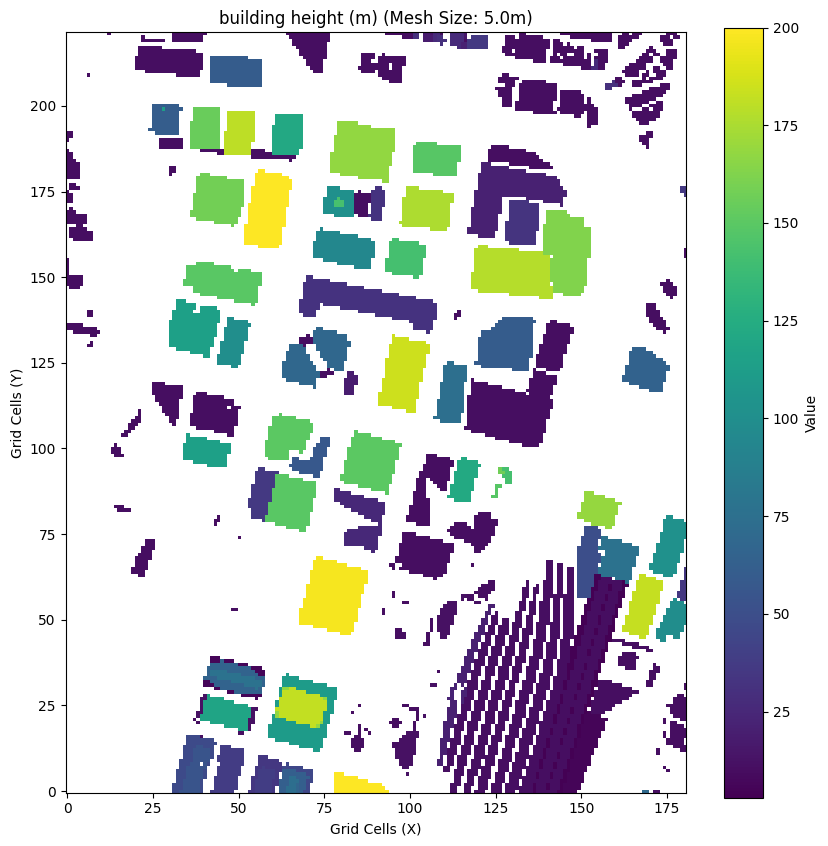

INFO | voxcity.voxcity.generator.grids | Creating Canopy Height grid
 
INFO | voxcity.voxcity.generator.grids | Data source: High Resolution 1m Global Canopy Height Maps


Generating URL ...
Please wait ...
Data downloaded to D:\repository\VoxCity\docs\examples\output\viz_demo\canopy_height.tif


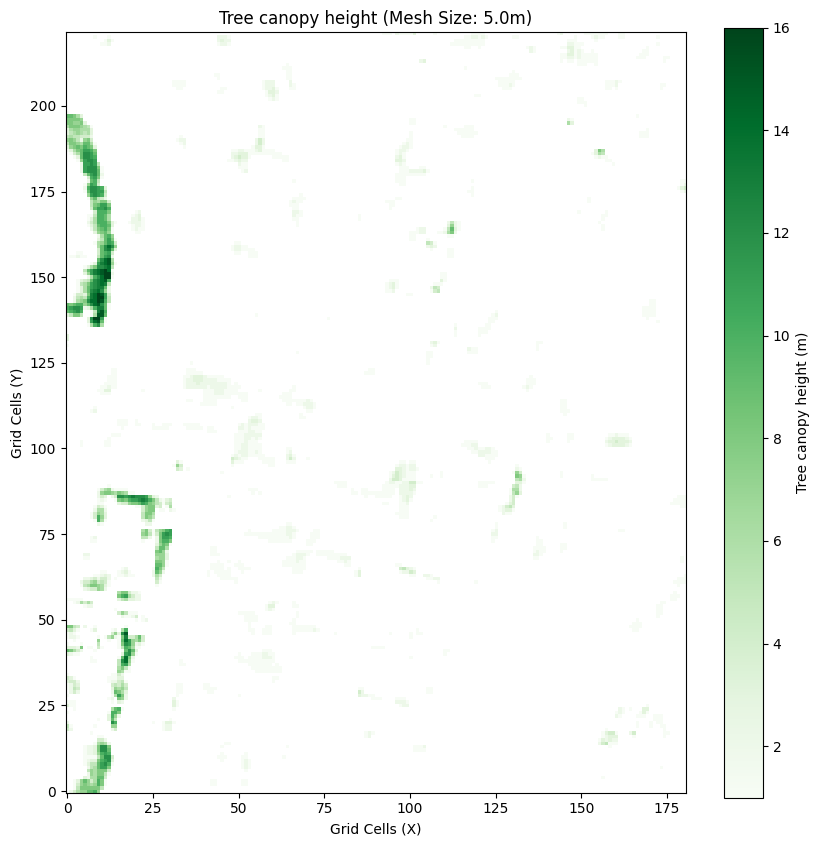

INFO | voxcity.voxcity.generator.grids | Creating Digital Elevation Model (DEM) grid
 
INFO | voxcity.voxcity.generator.grids | Data source: DeltaDTM


Generating URL ...
Please wait ...
Data downloaded to D:\repository\VoxCity\docs\examples\output\viz_demo\dem.tif


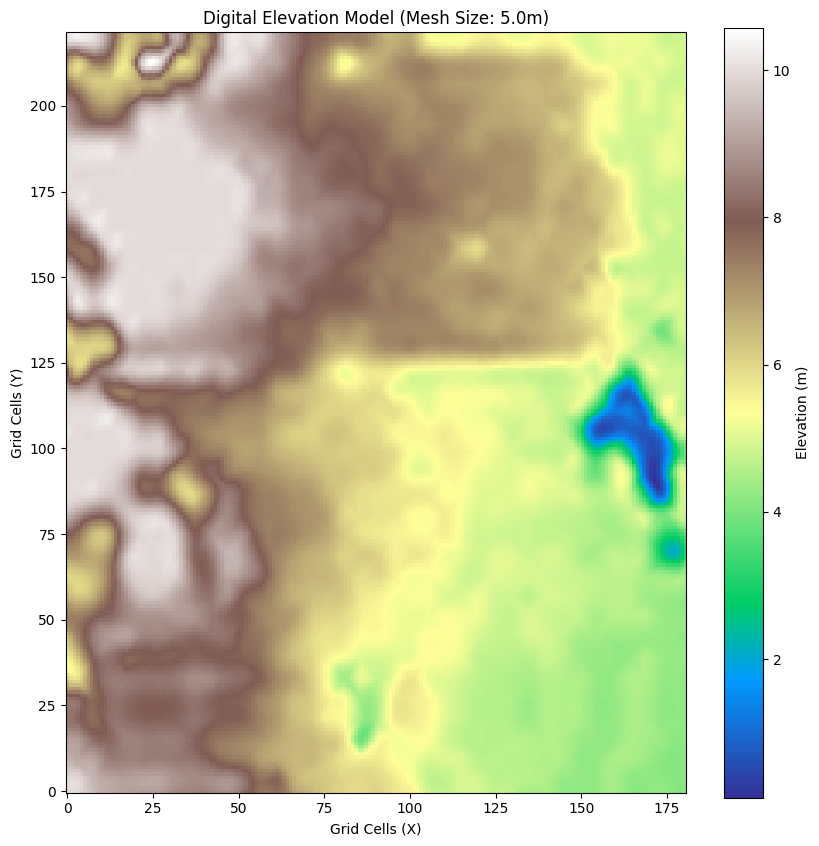

INFO | voxcity.voxcity.generator.voxelizer | Generating 3D voxel data
INFO | voxcity.voxcity.generator.voxelizer | 
Voxel Grid Semantic Codes:
  -3 : Building volume
  -2 : Tree canopy (vegetation)
  -1 : Ground/Subsurface
  >=1: Land cover class at ground surface (see Land Cover Classes)

INFO | voxcity.voxcity.generator.voxelizer | 
VoxCity Standard Land Cover Classes (1-based indices, used in voxel grids):
--------------------------------------------------
   1: Bareland           - Bare soil, rocks, desert
   2: Rangeland          - Grassland, pasture
   3: Shrub              - Shrubland, bushes
   4: Agriculture land   - Cropland, farmland
   5: Tree               - Forest, tree cover
   6: Moss and lichen    - Moss, lichen cover
   7: Wet land           - Wetland, marsh
   8: Mangrove           - Mangrove forest
   9: Water              - Water bodies
  10: Snow and ice       - Snow, ice, glaciers
  11: Developed space    - Urban areas, parking
  12: Road               - Roads, p

VoxCity results saved to output/viz_demo/voxcity.h5


(222, 181, 43)

In [1]:
# %pip install voxcity plotly

from voxcity.generator import get_voxcity
from voxcity.exporter.obj import export_obj
from voxcity.visualizer import visualize_voxcity, visualize_voxcity_plotly

meshsize = 5
rectangle_vertices = [
    (139.760, 35.680),
    (139.760, 35.690),
    (139.770, 35.690),
    (139.770, 35.680)
]

city = get_voxcity(
    rectangle_vertices,
    meshsize=meshsize,
    building_source='OpenStreetMap',
    land_cover_source='OpenStreetMap',
    canopy_height_source='High Resolution 1m Global Canopy Height Maps',
    dem_source='DeltaDTM',
    output_dir='output/viz_demo'
)

city.voxels.classes.shape


---
## 📦 OBJ 내보내기

외부 3D 소프트웨어에서 사용할 수 있도록 복셀 도시 모델을 Wavefront OBJ 형식으로 내보냅니다.

**지원되는 소프트웨어:** Blender, Rhino, SketchUp, 3ds Max, Maya, Cinema 4D

In [2]:
export_obj(city, output_dir='output/viz_demo', file_name='voxcity')
print('OBJ exported to output/viz_demo')


INFO | voxcity.voxcity.exporter.obj | OBJ and MTL files have been generated in output/viz_demo with the base name "voxcity".


OBJ exported to output/viz_demo


---
## 🖼️ 정적 및 대화형 시각화

### 정적 시각화 (PyVista)
직교 투영(orthographic) 또는 원근 투영(perspective)을 적용하여 다중 뷰 이미지를 렌더링합니다.

### 대화형 시각화 (Plotly)
주피터 노트북 내에서 3D 궤도(orbit) 제어가 가능한 3D 산점도(scatter plot)를 제공합니다.

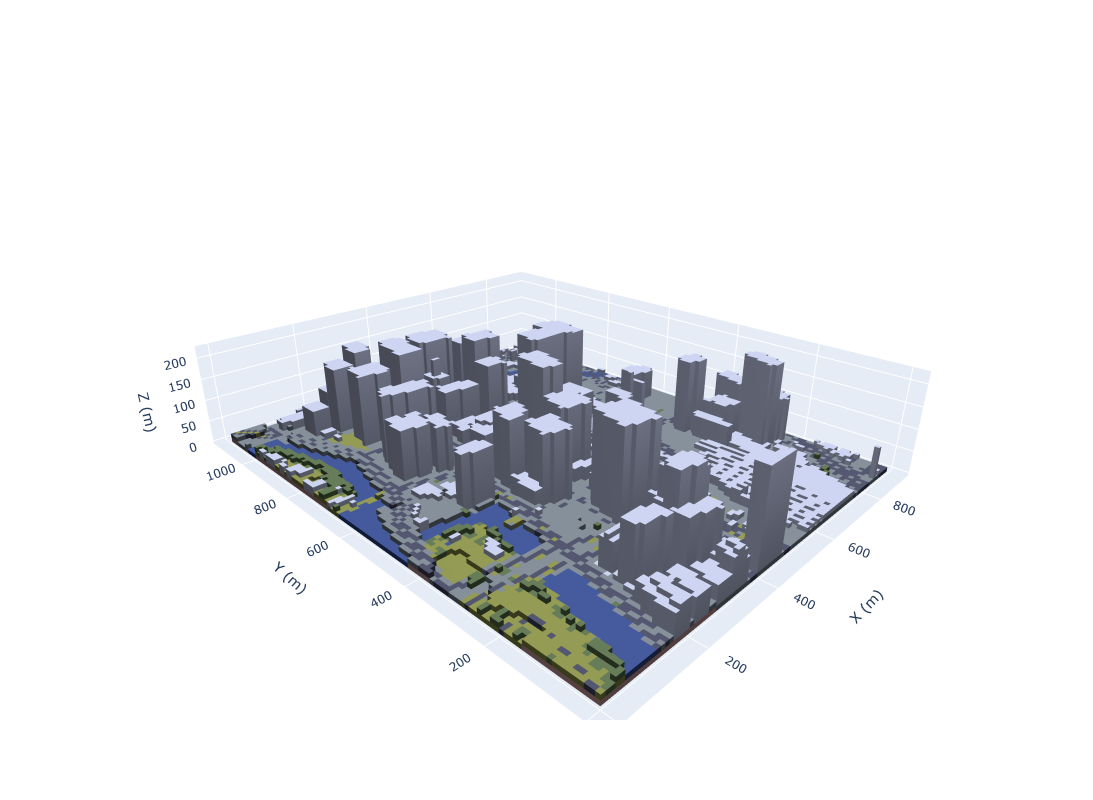

In [4]:
# 다중 뷰 정적 렌더링 (PyVista)
visualize_voxcity(
    city,
    mode="static",
    projection_type="perspective",
    distance_factor=1.2,
    output_directory="output/viz_demo"
)

# Plotly 대화형 피규어
fig = visualize_voxcity(city, mode="interactive", show=False, return_fig=True)
fig.show()


---
## 🎨 색상 매핑

VoxCity는 다양한 요소 유형에 대해 일관된 색상을 사용합니다:

| 유형 | 색상 | 코드 |
|------|-------|------|
| 건물 | 회색 | `[128, 128, 128]` |
| 나무 | 녹색 | `[34, 139, 34]` |
| 지표면 | 갈색 | `[139, 90, 43]` |
| 수면 | 파란색 | `[0, 0, 255]` |

## 다음 단계

- `demo_obj.ipynb` - 고급 OBJ 내보내기 옵션
- `demo_envi-met.ipynb` - CFD 시뮬레이션용 데이터 내보내기